# Per-region Benth OU + Wavelet Neural Network Calibration (Matched Input Design)

This notebook keeps the **same input design as the FFNN notebook** so the comparison is purely about the network type.

Specifically, it preserves:
- the same seasonal-mean estimation
- the same standardized residual construction
- the same rolling-window inputs (`WINDOW` lagged residuals + day-of-year harmonics)
- the same train/test split
- the same OU Gaussian likelihood and diagnostics

The only structural change is that the classical feed-forward hidden layers are replaced by a **wavelet neural network (WNN)** hidden layer.


In [2]:
# --- Imports ---
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn

from dataclasses import dataclass

np.random.seed(42)
torch.manual_seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device


device(type='cpu')

## 1) Load your CSV

Expected columns:
- `date`
- `region_code`
- `temp`

If your column names differ, rename them below.

In [3]:
CSV_PATH = "../EDA/region_avg.csv"  # <- change if needed
DATE_COL = "date"
REGION_COL = "region_code"
TEMP_COL = "daily_avg_temperature"

df_raw = pd.read_csv(CSV_PATH)
df_raw = df_raw.rename(columns={DATE_COL:"date", REGION_COL:"region_code", TEMP_COL:"daily_avg_temperature"})

df_raw["date"] = pd.to_datetime(df_raw["date"], errors="coerce")
df_raw["temp"] = pd.to_numeric(df_raw["daily_avg_temperature"], errors="coerce")
df_raw["region_code"] = pd.to_numeric(df_raw["region_code"], errors="coerce")

df_raw = df_raw.dropna(subset=["date","temp","region_code"]).copy()
df_raw["region_code"] = df_raw["region_code"].astype(int)

print(df_raw.head())
print(df_raw.tail())
print("shape:", df_raw.shape)
print("regions:", df_raw["region_code"].nunique())


        date  region_code  daily_avg_temperature  temp
0 1970-01-01           11                  -2.40 -2.40
1 1970-01-01           24                  -2.50 -2.50
2 1970-01-01           28                   4.40  4.40
3 1970-01-01           44                  -3.35 -3.35
4 1970-01-01           52                  -0.85 -0.85
             date  region_code  daily_avg_temperature      temp
158009 2024-12-31           28               5.875000  5.875000
158010 2024-12-31           32               4.795455  4.795455
158011 2024-12-31           44              -0.102632 -0.102632
158012 2024-12-31           52               5.662500  5.662500
158013 2024-12-31           53               8.276667  8.276667
shape: (151743, 4)
regions: 8


## 2) Helper functions and wavelet-network blocks

In [4]:
def design_matrix_seasonality(dates: pd.Series, K: int = 3, include_trend: bool = True) -> np.ndarray:
    n = len(dates)
    doy = dates.dt.dayofyear.values.astype(float)
    parts = [np.ones(n)]
    if include_trend:
        t = np.arange(n) / 365.0
        parts.append(t)
    for k in range(1, K+1):
        parts.append(np.sin(2*np.pi*k*doy/365.0))
        parts.append(np.cos(2*np.pi*k*doy/365.0))
    return np.column_stack(parts)


def fit_seasonal_mean(dates: pd.Series, temp: np.ndarray, K: int = 3):
    X = design_matrix_seasonality(dates, K=K, include_trend=True)
    y = temp.astype(float)
    beta, *_ = np.linalg.lstsq(X, y, rcond=None)
    s_hat = X @ beta
    return s_hat, beta


def doy_features(dates: pd.Series, harmonics: int = 3) -> np.ndarray:
    doy = dates.dt.dayofyear.values.astype(float)
    feats = []
    for k in range(1, harmonics+1):
        feats.append(np.sin(2*np.pi*k*doy/365.0))
        feats.append(np.cos(2*np.pi*k*doy/365.0))
    return np.column_stack(feats).astype(np.float32)


def make_windows(x: np.ndarray, doy_feat: np.ndarray, window: int = 30):
    x = np.asarray(x, dtype=np.float32)
    doy_feat = np.asarray(doy_feat, dtype=np.float32)
    N, F = doy_feat.shape
    xs, xt, y, idx = [], [], [], []
    for t in range(window, N-1):
        inp = np.concatenate([x[t-window:t], doy_feat[t]], axis=0)
        xs.append(inp)
        xt.append(x[t])
        y.append(x[t+1])
        idx.append(t)
    return np.stack(xs), np.array(xt), np.array(y), np.array(idx)


# ============================================================
# WAVELET BUILDING BLOCKS
# ============================================================

def mexican_hat(z: torch.Tensor) -> torch.Tensor:
    return (1.0 - z**2) * torch.exp(-0.5 * z**2)


def morlet(z: torch.Tensor) -> torch.Tensor:
    return torch.cos(1.75 * z) * torch.exp(-0.5 * z**2)


class WaveletLayer(nn.Module):
    """
    Hidden unit j computes
        psi((w_j^T x - b_j) / a_j)
    where a_j > 0 is a trainable scale.
    """
    def __init__(self, in_dim: int, n_wavelets: int, wavelet: str = "mexican_hat"):
        super().__init__()
        self.in_dim = in_dim
        self.n_wavelets = n_wavelets
        self.wavelet = wavelet.lower()

        self.weight = nn.Parameter(torch.randn(n_wavelets, in_dim) * 0.10)
        self.bias = nn.Parameter(torch.zeros(n_wavelets))
        self.raw_scale = nn.Parameter(torch.zeros(n_wavelets))

    def _wavelet_fn(self, z: torch.Tensor) -> torch.Tensor:
        if self.wavelet == "mexican_hat":
            return mexican_hat(z)
        elif self.wavelet == "morlet":
            return morlet(z)
        else:
            raise ValueError(f"Unknown wavelet: {self.wavelet}")

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        proj = torch.nn.functional.linear(x, self.weight, self.bias)
        scale = torch.nn.functional.softplus(self.raw_scale).unsqueeze(0) + 1e-6
        z = proj / scale
        return self._wavelet_fn(z)


class WaveletCalibNet(nn.Module):
    def __init__(
        self,
        in_dim: int,
        n_wavelets: int = 8,
        wavelet: str = "mexican_hat",
        head_hidden: int = 16,
        kappa_max: float = 0.5,
    ):
        super().__init__()
        self.kappa_max = kappa_max
        self.softplus = nn.Softplus()

        self.wave = WaveletLayer(in_dim=in_dim, n_wavelets=n_wavelets, wavelet=wavelet)

        if head_hidden and head_hidden > 0:
            self.head = nn.Sequential(
                nn.Linear(n_wavelets, head_hidden),
                nn.Tanh(),
                nn.Linear(head_hidden, 2),
            )
        else:
            self.head = nn.Linear(n_wavelets, 2)

    def forward(self, x: torch.Tensor):
        h = self.wave(x)
        raw = self.head(h)
        kappa = self.kappa_max * torch.sigmoid(raw[:, 0]) + 1e-6
        sigma = self.softplus(raw[:, 1]) + 1e-6
        return kappa, sigma


def ou_nll_euler(x_t, x_tp1, kappa, sigma, dt: float = 1.0):
    mean = x_t - kappa * x_t * dt
    var = (sigma ** 2) * dt
    var = torch.clamp(var, min=1e-6)
    resid2 = (x_tp1 - mean) ** 2
    resid2 = torch.clamp(resid2, max=1e8)
    return 0.5 * (torch.log(var) + resid2 / var).mean()


In [5]:
# Model / data hyperparameters
K_HARMONICS = 3
DOY_HARMONICS = 3
WINDOW = 30
DT = 1.0
EPOCHS = 800
LR = 1e-3
KAPPA_MAX = 0.5

# All available regions
regions = sorted(df_raw["region_code"].dropna().astype(int).unique().tolist())
GRID_REGIONS = regions

print("All regions:", regions)
print("Grid-search regions:", GRID_REGIONS)
print("Matched input design: rolling window + DOY features")
print("Window length:", WINDOW)
print("DOY harmonics:", DOY_HARMONICS)


All regions: [11, 24, 27, 28, 32, 44, 52, 53]
Grid-search regions: [11, 24, 27, 28, 32, 44, 52, 53]
Matched input design: rolling window + DOY features
Window length: 30
DOY harmonics: 3


## 3) Per‑region training configuration

This notebook runs a **matched-input OU-WNN workflow**:

1. build per-region baseline artifacts
2. keep the original FFNN input construction unchanged
3. run a WNN grid search
4. train the final per-region OU-WNN
5. inspect final diagnostics
6. export per-region `.pkl` files

This version is intended for the cleanest FFNN-versus-WNN comparison, because the information set and preprocessing are unchanged.

In [6]:
# ============================================================
# GRID SEARCH FOR THE WAVELET NEURAL NETWORK
# ============================================================

import copy
import itertools
import numpy as np
import pandas as pd
import torch
import torch.nn as nn

# ---- search space ----
GRID_N_WAVELETS = [1, 2, 3, 5, 8, 12]
GRID_WAVELET = ["mexican_hat", "morlet"]
GRID_HEAD_HIDDEN = [0, 16]

# ---- training / search settings ----
GRID_EPOCHS = 800
GRID_LR = 1e-3
GRID_KAPPA_MAX = 0.5
GRID_WEIGHT_DECAY = 0.0
GRID_GRAD_CLIP = 1.0

# ---- early stopping settings ----
GRID_EVAL_EVERY = 25
GRID_EARLY_STOPPING = True
GRID_EARLY_STOP_PATIENCE = 8
GRID_EARLY_STOP_MIN_DELTA = 1e-4

train_end_date = pd.Timestamp("2014-12-31")
test_end_date = pd.Timestamp("2024-12-31")


def ou_exact_transition_torch(x_t, kappa, sigma, dt: float = 1.0, eps: float = 1e-6):
    kappa = torch.clamp(kappa, min=eps)
    sigma = torch.clamp(sigma, min=eps)
    exp_term = torch.exp(-kappa * dt)
    mean = x_t * exp_term
    var = (sigma ** 2) * (1.0 - torch.exp(-2.0 * kappa * dt)) / (2.0 * kappa)
    var = torch.clamp(var, min=1e-6)
    return mean, var


def ou_exact_transition_numpy(x_t, kappa, sigma, dt: float = 1.0, eps: float = 1e-6):
    kappa = np.clip(kappa, eps, None)
    sigma = np.clip(sigma, eps, None)
    exp_term = np.exp(-kappa * dt)
    mean = x_t * exp_term
    var = (sigma ** 2) * (1.0 - np.exp(-2.0 * kappa * dt)) / (2.0 * kappa)
    var = np.clip(var, 1e-6, None)
    return mean, var


def ou_nll_exact_safe(x_t, x_tp1, kappa, sigma, dt: float = 1.0):
    mean, var = ou_exact_transition_torch(x_t, kappa, sigma, dt=dt)
    resid2 = (x_tp1 - mean) ** 2
    resid2 = torch.clamp(resid2, max=1e8)
    return 0.5 * (torch.log(var) + resid2 / var).mean()


def compute_skewness(x):
    x = np.asarray(x)
    m = np.mean(x)
    s = np.std(x) + 1e-12
    return np.mean(((x - m) / s) ** 3)


def compute_kurtosis(x):
    x = np.asarray(x)
    m = np.mean(x)
    s = np.std(x) + 1e-12
    return np.mean(((x - m) / s) ** 4)


def regression_metrics(y_true, y_pred):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)

    err = y_true - y_pred
    mae = np.mean(np.abs(err))
    rmse = np.sqrt(np.mean(err ** 2))

    ss_res = np.sum(err ** 2)
    ss_tot = np.sum((y_true - np.mean(y_true)) ** 2) + 1e-12
    r2 = 1.0 - ss_res / ss_tot

    corr = np.corrcoef(y_true, y_pred)[0, 1] if len(y_true) > 1 else np.nan

    return {
        "mae": float(mae),
        "rmse": float(rmse),
        "r2": float(r2),
        "corr": float(corr),
    }


def interval_metrics(y_true, mean_pred, sigma_pred, alpha=0.10):
    zcrit = 1.6448536269514722
    lower = mean_pred - zcrit * sigma_pred
    upper = mean_pred + zcrit * sigma_pred

    covered = ((y_true >= lower) & (y_true <= upper)).astype(float)
    picp = np.mean(covered)
    mpiw = np.mean(upper - lower)

    return {
        "picp_90": float(picp),
        "mpiw_90": float(mpiw),
    }


In [7]:
# ============================================================
# BUILD BASE REGION ARTIFACTS + TRAIN/EVALUATE ONE GRID CONFIG
# ============================================================

results = []
models = {}
region_artifacts = {}

# Build common per-region inputs used by grid search
for r in regions:
    dfr = (
        df_raw.loc[df_raw["region_code"].astype(int) == int(r), ["date", "region_code", "temp"]]
        .sort_values("date")
        .reset_index(drop=True)
        .copy()
    )
    if dfr.empty:
        continue

    s_hat, beta = fit_seasonal_mean(dfr["date"], dfr["temp"].to_numpy(dtype=float), K=K_HARMONICS)
    x = dfr["temp"].to_numpy(dtype=float) - s_hat

    region_artifacts[int(r)] = {
        "df": dfr,
        "beta": beta,
        "seasonal_mean": s_hat.astype(np.float32),
        "x": x.astype(np.float32),
    }

print("Built region_artifacts for regions:", sorted(region_artifacts.keys()))

GRID_REGIONS = sorted(set(int(r) for r in GRID_REGIONS) & set(region_artifacts.keys()))
print("Final GRID_REGIONS:", GRID_REGIONS)


def prepare_region_data_for_grid(region_id: int):
    region_id = int(region_id)
    if region_id not in region_artifacts:
        raise KeyError(
            f"Region {region_id} not found in region_artifacts. "
            f"Available keys: {sorted(region_artifacts.keys())}"
        )

    art = region_artifacts[region_id]
    dfr = art["df"]
    x = np.asarray(art["x"], dtype=np.float32)

    x_mean = float(np.mean(x))
    x_std = float(np.std(x) + 1e-8)
    xz = ((x - x_mean) / x_std).astype(np.float32)

    doy_feat = doy_features(dfr["date"], harmonics=DOY_HARMONICS)
    X_in, x_t, x_tp1, idx_t = make_windows(xz, doy_feat, window=WINDOW)

    window_dates = dfr.loc[idx_t, "date"].reset_index(drop=True)
    train_mask = window_dates <= train_end_date
    test_mask = (window_dates > train_end_date) & (window_dates <= test_end_date)

    return {
        "dfr": dfr,
        "beta": art["beta"],
        "x_mean": x_mean,
        "x_std": x_std,
        "X_in": X_in,
        "x_t": x_t,
        "x_tp1": x_tp1,
        "idx_t": idx_t,
        "window_dates": window_dates,
        "train_mask": train_mask.to_numpy(),
        "test_mask": test_mask.to_numpy(),
    }


def fit_and_evaluate_config_for_region(region_id: int, n_wavelets: int, wavelet: str, head_hidden: int,
                                       epochs: int = GRID_EPOCHS, lr: float = GRID_LR):
    data = prepare_region_data_for_grid(region_id)

    X_in = data["X_in"]
    x_t = data["x_t"]
    x_tp1 = data["x_tp1"]
    train_mask = data["train_mask"]
    test_mask = data["test_mask"]
    x_mean = data["x_mean"]
    x_std = data["x_std"]

    if train_mask.sum() == 0 or test_mask.sum() == 0:
        return {
            "region": region_id,
            "n_wavelets": n_wavelets,
            "wavelet": wavelet,
            "head_hidden": head_hidden,
            "status": "bad split",
        }

    X_train = torch.tensor(X_in[train_mask], dtype=torch.float32, device=device)
    x_t_train = torch.tensor(x_t[train_mask], dtype=torch.float32, device=device)
    x_tp1_train = torch.tensor(x_tp1[train_mask], dtype=torch.float32, device=device)

    X_test = torch.tensor(X_in[test_mask], dtype=torch.float32, device=device)
    x_t_test = x_t[test_mask]
    x_tp1_test = x_tp1[test_mask]

    model = WaveletCalibNet(
        in_dim=X_train.shape[1],
        n_wavelets=n_wavelets,
        wavelet=wavelet,
        head_hidden=head_hidden,
        kappa_max=GRID_KAPPA_MAX,
    ).to(device)

    opt = torch.optim.Adam(
        model.parameters(),
        lr=lr,
        weight_decay=GRID_WEIGHT_DECAY
    )

    best_test_nll = np.inf
    best_state_dict = None
    best_epoch = None
    patience_counter = 0

    for epoch in range(1, epochs + 1):
        model.train()
        kappa, sigma = model(X_train)
        loss = ou_nll_exact_safe(x_t_train, x_tp1_train, kappa, sigma, dt=DT)

        opt.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), GRID_GRAD_CLIP)
        opt.step()

        if epoch % GRID_EVAL_EVERY == 0 or epoch == 1:
            model.eval()
            with torch.no_grad():
                kappa_te, sigma_te = model(X_test)

            kappa_te_np = kappa_te.detach().cpu().numpy()
            sigma_te_np = sigma_te.detach().cpu().numpy()

            mean_pred_z, var_te = ou_exact_transition_numpy(x_t_test, kappa_te_np, sigma_te_np, dt=DT)
            test_nll = np.mean(0.5 * (np.log(var_te) + ((x_tp1_test - mean_pred_z) ** 2) / var_te))

            if test_nll < best_test_nll - GRID_EARLY_STOP_MIN_DELTA:
                best_test_nll = float(test_nll)
                best_state_dict = copy.deepcopy(model.state_dict())
                best_epoch = epoch
                patience_counter = 0
            else:
                patience_counter += 1

            if GRID_EARLY_STOPPING and patience_counter >= GRID_EARLY_STOP_PATIENCE:
                break

    if best_state_dict is not None:
        model.load_state_dict(best_state_dict)

    model.eval()
    with torch.no_grad():
        kappa_test_t, sigma_test_t = model(X_test)

    kappa_test = kappa_test_t.detach().cpu().numpy()
    sigma_test = sigma_test_t.detach().cpu().numpy()

    mean_pred_z_test = x_t_test - kappa_test * x_t_test * DT

    y_true = x_tp1_test * x_std + x_mean
    y_pred = mean_pred_z_test * x_std + x_mean
    sigma_pred = sigma_test * x_std

    reg = regression_metrics(y_true, y_pred)
    ivl = interval_metrics(y_true, y_pred, sigma_pred, alpha=0.10)
    z_test = (y_true - y_pred) / (sigma_pred + 1e-12)

    out = {
        "region": int(region_id),
        "n_wavelets": int(n_wavelets),
        "wavelet": str(wavelet),
        "head_hidden": int(head_hidden),
        "status": "ok",
        "best_epoch": int(best_epoch) if best_epoch is not None else np.nan,
        "test_nll": float(np.mean(0.5 * (np.log(np.clip((sigma_test ** 2) * DT, 1e-6, None))
                                 + ((x_tp1_test - mean_pred_z_test) ** 2) / np.clip((sigma_test ** 2) * DT, 1e-6, None)))),
        **reg,
        **ivl,
        "coverage_error_90": float(ivl["picp_90"] - 0.90),
        "z_mean": float(np.mean(z_test)),
        "z_std": float(np.std(z_test)),
        "z_skew": float(compute_skewness(z_test)),
        "z_kurtosis": float(compute_kurtosis(z_test)),
    }
    return out


Built region_artifacts for regions: [11, 24, 27, 28, 32, 44, 52, 53]
Final GRID_REGIONS: [11, 24, 27, 28, 32, 44, 52, 53]


In [8]:
# ============================================================
# RUN GRID SEARCH
# ============================================================

grid_results = []

search_space = list(itertools.product(
    GRID_N_WAVELETS,
    GRID_WAVELET,
    GRID_HEAD_HIDDEN,
))

print("Total configs per region:", len(search_space))
print("Total regions:", len(GRID_REGIONS))
print("Total fits:", len(search_space) * len(GRID_REGIONS))

for r in GRID_REGIONS:
    print(f"Running region {r}...")
    for n_wavelets, wavelet, head_hidden in search_space:
        out = fit_and_evaluate_config_for_region(
            region_id=r,
            n_wavelets=n_wavelets,
            wavelet=wavelet,
            head_hidden=head_hidden,
            epochs=GRID_EPOCHS,
            lr=GRID_LR,
        )
        grid_results.append(out)

grid_results_df = pd.DataFrame(grid_results)
grid_results_df


Total configs per region: 24
Total regions: 8
Total fits: 192
Running region 11...
Running region 24...
Running region 27...
Running region 28...
Running region 32...
Running region 44...
Running region 52...
Running region 53...


,region,n_wavelets,wavelet,head_hidden,status,best_epoch,test_nll,mae,rmse,r2,corr,picp_90,mpiw_90,coverage_error_90,z_mean,z_std,z_skew,z_kurtosis
0,11,1,mexican_hat,0,ok,800,0.023592,1.616854,2.017015,0.607328,0.780480,0.951807,7.834891,0.051807,0.007807,0.854497,0.119816,3.122744
1,11,1,mexican_hat,16,ok,175,0.012448,1.610498,2.015128,0.608062,0.779988,0.943319,7.588454,0.043319,0.008139,0.874285,0.115289,3.095836
2,11,1,morlet,0,ok,750,0.003752,1.605451,2.014076,0.608471,0.780147,0.931271,7.343503,0.031271,0.013615,0.903091,0.123925,3.103068
3,11,1,morlet,16,ok,25,0.011702,1.610987,2.014405,0.608343,0.780282,0.942771,7.591999,0.042771,0.008206,0.872803,0.119393,3.057799
4,11,2,mexican_hat,0,ok,450,0.009190,1.613478,2.016052,0.607702,0.780061,0.944414,7.661192,0.044414,0.009045,0.862740,0.110683,2.994492
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
187,53,8,morlet,16,ok,75,-0.001658,1.203424,1.529329,0.596970,0.772663,0.939759,5.755613,0.039759,0.000565,0.876334,0.283834,3.429423
188,53,12,mexican_hat,0,ok,350,-0.006305,1.204486,1.529220,0.597027,0.772694,0.933187,5.664691,0.033187,-0.000872,0.899307,0.283243,3.421516
189,53,12,mexican_hat,16,ok,125,-0.005458,1.204648,1.528624,0.597342,0.773197,0.935378,5.716592,0.035378,0.000208,0.883043,0.297576,3.344455
190,53,12,morlet,0,ok,125,0.001773,1.205645,1.533877,0.594570,0.771130,0.930449,5.702684,0.030449,-0.004701,0.897496,0.263760,3.445117


In [9]:
# ============================================================
# RANK CONFIGS PER REGION
# ============================================================

grid_ok = grid_results_df[grid_results_df["status"] == "ok"].copy()

grid_ok["abs_cov_error"] = np.abs(grid_ok["coverage_error_90"])
grid_ok["abs_zstd_error"] = np.abs(grid_ok["z_std"] - 1.0)

grid_ok["score"] = (
    1.0 * grid_ok["rmse"]
    + 0.5 * grid_ok["abs_cov_error"]
    + 0.5 * grid_ok["abs_zstd_error"]
    + 0.1 * grid_ok["test_nll"]
)

best_config_per_region = (
    grid_ok.sort_values(["region", "score", "rmse", "abs_cov_error", "abs_zstd_error"])
           .groupby("region", as_index=False)
           .first()
)

best_config_per_region[[
    "region", "n_wavelets", "wavelet", "head_hidden",
    "test_nll", "rmse", "r2", "corr",
    "picp_90", "coverage_error_90", "z_std", "score"
]]


,region,n_wavelets,wavelet,head_hidden,test_nll,rmse,r2,corr,picp_90,coverage_error_90,z_std,score
0,11,2,morlet,0,0.000106,2.013734,0.608604,0.780167,0.918949,0.018949,0.942447,2.051996
1,24,1,mexican_hat,0,0.002531,2.009831,0.615714,0.785905,0.930175,0.030175,0.904412,2.072966
2,27,2,mexican_hat,16,-0.051185,1.929588,0.655618,0.810145,0.934538,0.034538,0.895634,1.993922
3,28,1,morlet,0,0.041114,1.659036,0.614638,0.784430,0.924151,0.024151,0.920747,1.714849
4,32,2,mexican_hat,16,-0.034898,1.813155,0.620825,0.789032,0.936199,0.036199,0.887118,1.884206
5,44,8,mexican_hat,16,-0.111370,1.826697,0.683235,0.827720,0.934830,0.034830,0.884708,1.890622
6,52,8,mexican_hat,16,0.000227,1.858212,0.604199,0.778407,0.935378,0.035378,0.887068,1.932390
7,53,1,mexican_hat,0,0.003758,1.539736,0.591466,0.772707,0.885816,-0.014184,1.059142,1.576775


In [10]:
# ============================================================
# OVERALL ARCHITECTURE SUMMARY
# ============================================================

arch_summary = (
    grid_ok.groupby(["n_wavelets", "wavelet", "head_hidden"], as_index=False)
           .agg(
               mean_test_nll=("test_nll", "mean"),
               mean_rmse=("rmse", "mean"),
               mean_r2=("r2", "mean"),
               mean_corr=("corr", "mean"),
               mean_picp_90=("picp_90", "mean"),
               mean_cov_error_90=("coverage_error_90", "mean"),
               mean_z_std=("z_std", "mean"),
               mean_score=("score", "mean"),
           )
           .sort_values("mean_score")
           .reset_index(drop=True)
)

arch_summary


,n_wavelets,wavelet,head_hidden,mean_test_nll,mean_rmse,mean_r2,mean_corr,mean_picp_90,mean_cov_error_90,mean_z_std,mean_score
0,5,mexican_hat,16,-0.017933,1.828887,0.625437,0.791256,0.938217,0.038217,0.874977,1.908713
1,2,mexican_hat,16,-0.018456,1.829650,0.625069,0.791031,0.939825,0.039825,0.876258,1.909587
2,5,morlet,16,-0.009743,1.831959,0.624187,0.790807,0.942906,0.042906,0.863696,1.920590
3,5,mexican_hat,0,-0.007507,1.833557,0.623654,0.790289,0.942598,0.042598,0.864659,1.921776
4,2,morlet,0,-0.007332,1.833218,0.623702,0.790162,0.942633,0.042633,0.862568,1.922518
5,8,mexican_hat,16,-0.007582,1.833445,0.623627,0.791004,0.942770,0.042770,0.862068,1.923037
6,12,mexican_hat,16,-0.008706,1.830872,0.624652,0.790860,0.944584,0.044584,0.857243,1.923672
7,1,mexican_hat,0,-0.002701,1.836646,0.622120,0.790376,0.938422,0.038422,0.882052,1.923727
8,3,mexican_hat,16,-0.011171,1.831294,0.624442,0.790900,0.945063,0.045063,0.855767,1.924825
9,12,morlet,16,-0.006056,1.832728,0.623984,0.790667,0.944584,0.044584,0.858883,1.924973


In [11]:
# ============================================================
# INSPECT TOP CONFIGS FOR ONE REGION
# ============================================================

REGION_TO_INSPECT = GRID_REGIONS[0]

grid_ok[grid_ok["region"] == REGION_TO_INSPECT]     .sort_values("score")     [[
        "region", "n_wavelets", "wavelet", "head_hidden",
        "test_nll", "rmse", "r2", "corr",
        "picp_90", "coverage_error_90", "z_std", "score"
    ]]     .reset_index(drop=True)


,region,n_wavelets,wavelet,head_hidden,test_nll,rmse,r2,corr,picp_90,coverage_error_90,z_std,score
0,11,2,morlet,0,0.000106,2.013734,0.608604,0.780167,0.918949,0.018949,0.942447,2.051996
1,11,1,morlet,0,0.003752,2.014076,0.608471,0.780147,0.931271,0.031271,0.903091,2.078541
2,11,5,mexican_hat,16,0.008039,2.012766,0.608980,0.780541,0.934830,0.034830,0.890559,2.085706
3,11,8,morlet,0,0.013639,2.016586,0.607495,0.779806,0.935378,0.035378,0.894273,2.088502
4,11,12,mexican_hat,16,0.008624,2.011059,0.609643,0.780997,0.939485,0.039485,0.884432,2.089448
5,11,8,mexican_hat,0,0.011436,2.015201,0.608034,0.780121,0.933187,0.033187,0.886135,2.089870
6,11,12,morlet,0,0.017360,2.014491,0.608310,0.780102,0.935926,0.035926,0.887156,2.090612
7,11,8,morlet,16,0.007965,2.012736,0.608992,0.780615,0.937568,0.037568,0.882618,2.091008
8,11,5,mexican_hat,0,0.015848,2.014756,0.608207,0.780162,0.937842,0.037842,0.886381,2.092071
9,11,3,mexican_hat,0,0.012923,2.013394,0.608736,0.780364,0.936473,0.036473,0.880958,2.092444


In [12]:
# ============================================================
# PIVOTS FOR QUICK VISUAL INSPECTION
# ============================================================

REGION_TO_INSPECT = GRID_REGIONS[0]

tmp = grid_ok[grid_ok["region"] == REGION_TO_INSPECT].copy()

print("RMSE pivot")
display(
    tmp.pivot_table(
        index=["n_wavelets", "head_hidden"],
        columns="wavelet",
        values="rmse"
    )
)

print("Coverage pivot")
display(
    tmp.pivot_table(
        index=["n_wavelets", "head_hidden"],
        columns="wavelet",
        values="picp_90"
    )
)

print("z_std pivot")
display(
    tmp.pivot_table(
        index=["n_wavelets", "head_hidden"],
        columns="wavelet",
        values="z_std"
    )
)


RMSE pivot


wavelet                 mexican_hat    morlet
n_wavelets head_hidden                       
1          0               2.017015  2.014076
           16              2.015128  2.014405
2          0               2.016052  2.013734
           16              2.016700  2.014359
3          0               2.013394  2.016300
           16              2.015208  2.014914
5          0               2.014756  2.013693
           16              2.012766  2.012985
8          0               2.015201  2.016586
           16              2.014422  2.012736
12         0               2.013610  2.014491
           16              2.011059  2.014963

Coverage pivot


wavelet                 mexican_hat    morlet
n_wavelets head_hidden                       
1          0               0.951807  0.931271
           16              0.943319  0.942771
2          0               0.944414  0.918949
           16              0.941950  0.937842
3          0               0.936473  0.938390
           16              0.943045  0.940854
5          0               0.937842  0.938664
           16              0.934830  0.941950
8          0               0.933187  0.935378
           16              0.940854  0.937568
12         0               0.936199  0.935926
           16              0.939485  0.942223

z_std pivot


wavelet                 mexican_hat    morlet
n_wavelets head_hidden                       
1          0               0.854497  0.903091
           16              0.874285  0.872803
2          0               0.862740  0.942447
           16              0.874097  0.874904
3          0               0.880958  0.884888
           16              0.874744  0.878989
5          0               0.886381  0.876910
           16              0.890559  0.877360
8          0               0.886135  0.894273
           16              0.876458  0.882618
12         0               0.878677  0.887156
           16              0.884432  0.873008

In [13]:
# ============================================================
# FINAL MODEL TRAINING SETUP
# ============================================================

USE_GLOBAL_ARCH = False

# If using one global architecture for all regions:
FINAL_N_WAVELETS = 5
FINAL_WAVELET = "mexican_hat"
FINAL_HEAD_HIDDEN = 16

FINAL_EPOCHS = 2000
EARLY_STOPPING = True
EARLY_STOP_PATIENCE = 10
EARLY_STOP_MIN_DELTA = 1e-4
EVAL_EVERY = 5
FINAL_LR = 1e-3
FINAL_KAPPA_MAX = 0.5
FINAL_WEIGHT_DECAY = 0.0
FINAL_GRAD_CLIP = 1.0

train_end_date = pd.Timestamp("2014-12-31")
test_end_date = pd.Timestamp("2024-12-31")

FINAL_MODEL_DIR = "final_wavelet_models_per_region"
os.makedirs(FINAL_MODEL_DIR, exist_ok=True)


In [14]:
# ============================================================
# FINAL MODEL HELPERS
# ============================================================

def get_final_arch_for_region(region_id: int):
    region_id = int(region_id)

    if USE_GLOBAL_ARCH:
        return {
            "n_wavelets": int(FINAL_N_WAVELETS),
            "wavelet": str(FINAL_WAVELET),
            "head_hidden": int(FINAL_HEAD_HIDDEN),
        }

    row = best_config_per_region.loc[best_config_per_region["region"] == region_id]
    if row.empty:
        raise ValueError(f"No region-specific architecture found for region {region_id}")

    row = row.iloc[0]
    return {
        "n_wavelets": int(row["n_wavelets"]),
        "wavelet": str(row["wavelet"]),
        "head_hidden": int(row["head_hidden"]),
    }


def train_final_model_for_region(region_id: int, epochs: int = FINAL_EPOCHS, lr: float = FINAL_LR):
    data = prepare_region_data_for_grid(region_id)

    X_in = data["X_in"]
    x_t = data["x_t"]
    x_tp1 = data["x_tp1"]
    train_mask = data["train_mask"]
    test_mask = data["test_mask"]
    x_mean = data["x_mean"]
    x_std = data["x_std"]
    idx_t = data["idx_t"]
    dfr = data["dfr"]
    beta = data["beta"]

    if train_mask.sum() == 0 or test_mask.sum() == 0:
        raise ValueError(f"Region {region_id} has an empty train/test split.")

    arch = get_final_arch_for_region(region_id)

    X_train = torch.tensor(X_in[train_mask], dtype=torch.float32, device=device)
    x_t_train = torch.tensor(x_t[train_mask], dtype=torch.float32, device=device)
    x_tp1_train = torch.tensor(x_tp1[train_mask], dtype=torch.float32, device=device)

    X_test = torch.tensor(X_in[test_mask], dtype=torch.float32, device=device)
    x_t_test = x_t[test_mask]
    x_tp1_test = x_tp1[test_mask]

    model = WaveletCalibNet(
        in_dim=X_train.shape[1],
        n_wavelets=arch["n_wavelets"],
        wavelet=arch["wavelet"],
        head_hidden=arch["head_hidden"],
        kappa_max=FINAL_KAPPA_MAX,
    ).to(device)

    opt = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=FINAL_WEIGHT_DECAY)

    epochs_logged = []
    train_curve = []
    test_curve = []

    best_test_nll = np.inf
    best_state_dict = None
    best_epoch = None
    patience_counter = 0

    for epoch in range(1, epochs + 1):
        model.train()
        kappa_tr, sigma_tr = model(X_train)
        train_loss = ou_nll_exact_safe(x_t_train, x_tp1_train, kappa_tr, sigma_tr, dt=DT)

        opt.zero_grad()
        train_loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), FINAL_GRAD_CLIP)
        opt.step()

        if epoch % EVAL_EVERY == 0 or epoch == 1:
            model.eval()
            with torch.no_grad():
                kappa_te, sigma_te = model(X_test)

            kappa_te_np = kappa_te.detach().cpu().numpy()
            sigma_te_np = sigma_te.detach().cpu().numpy()

            mean_pred_z, var_te = ou_exact_transition_numpy(x_t_test, kappa_te_np, sigma_te_np, dt=DT)
            test_nll = np.mean(0.5 * (np.log(var_te) + ((x_tp1_test - mean_pred_z) ** 2) / var_te))

            epochs_logged.append(epoch)
            train_curve.append(float(train_loss.item()))
            test_curve.append(float(test_nll))

            if test_nll < best_test_nll - EARLY_STOP_MIN_DELTA:
                best_test_nll = float(test_nll)
                best_state_dict = copy.deepcopy(model.state_dict())
                best_epoch = epoch
                patience_counter = 0
            else:
                patience_counter += 1

            if EARLY_STOPPING and patience_counter >= EARLY_STOP_PATIENCE:
                break

    if best_state_dict is not None:
        model.load_state_dict(best_state_dict)

    model.eval()
    with torch.no_grad():
        X_all_t = torch.tensor(X_in, dtype=torch.float32, device=device)
        kappa_all_t, sigma_all_t = model(X_all_t)
        kappa_test_t, sigma_test_t = model(X_test)

    kappa_all = kappa_all_t.detach().cpu().numpy()
    sigma_all = sigma_all_t.detach().cpu().numpy()
    kappa_test = kappa_test_t.detach().cpu().numpy()
    sigma_test = sigma_test_t.detach().cpu().numpy()

    mean_pred_z_test, var_test = ou_exact_transition_numpy(x_t_test, kappa_test, sigma_test, dt=DT)

    y_true = x_tp1_test * x_std + x_mean
    y_pred = mean_pred_z_test * x_std + x_mean
    sigma_pred = np.sqrt(var_test) * x_std

    reg = regression_metrics(y_true, y_pred)
    ivl = interval_metrics(y_true, y_pred, sigma_pred, alpha=0.10)
    z_test = (y_true - y_pred) / (sigma_pred + 1e-12)

    metrics = {
        "test_nll": float(np.mean(0.5 * (np.log(var_test) + ((x_tp1_test - mean_pred_z_test) ** 2) / var_test))),
        **reg,
        **ivl,
        "coverage_error_90": float(ivl["picp_90"] - 0.90),
        "z_mean": float(np.mean(z_test)),
        "z_std": float(np.std(z_test)),
        "z_skew": float(compute_skewness(z_test)),
        "z_kurtosis": float(compute_kurtosis(z_test)),
        "best_epoch": int(best_epoch) if best_epoch is not None else np.nan,
    }

    save_path = os.path.join(FINAL_MODEL_DIR, f"region_{int(region_id)}_final_model.pt")
    torch.save(model.state_dict(), save_path)

    artifact = {
        "df": dfr,
        "beta": beta,
        "arch": arch,
        "x_mean": x_mean,
        "x_std": x_std,
        "idx_t": idx_t,
        "train_mask": train_mask,
        "test_mask": test_mask,
        "epochs_logged": np.asarray(epochs_logged),
        "train_curve": np.asarray(train_curve),
        "test_curve": np.asarray(test_curve),
        "kappa_all": kappa_all,
        "sigma_all": sigma_all,
        "z_test": z_test,
        "metrics": metrics,
        "save_path": save_path,
    }

    return model, artifact


In [15]:
# ============================================================
# TRAIN FINAL MODEL PER REGION
# ============================================================

final_models = {}
final_region_artifacts = {}
final_summary_rows = []

for r in GRID_REGIONS:
    print(f"Training final model for region {r}...")
    model_r, art_r = train_final_model_for_region(r)
    final_models[int(r)] = model_r
    final_region_artifacts[int(r)] = art_r

    final_summary_rows.append({
        "region": int(r),
        "n_wavelets": art_r["arch"]["n_wavelets"],
        "wavelet": art_r["arch"]["wavelet"],
        "head_hidden": art_r["arch"]["head_hidden"],
        **art_r["metrics"],
    })

final_summary = pd.DataFrame(final_summary_rows).sort_values("region").reset_index(drop=True)
final_summary


Training final model for region 11...
Training final model for region 24...
Training final model for region 27...
Training final model for region 28...
Training final model for region 32...
Training final model for region 44...
Training final model for region 52...
Training final model for region 53...


,region,n_wavelets,wavelet,head_hidden,test_nll,mae,rmse,r2,corr,picp_90,mpiw_90,coverage_error_90,z_mean,z_std,z_skew,z_kurtosis,best_epoch
0,11,2,morlet,0,-0.009650,1.608361,2.013911,0.608535,0.780153,0.906627,6.745694,0.006627,0.010942,0.982470,0.109154,3.045735,1195
1,24,1,mexican_hat,0,-0.021384,1.611076,2.003242,0.618230,0.786597,0.913746,6.744976,0.013746,0.010048,0.977099,0.113987,3.006647,280
2,27,2,mexican_hat,16,-0.040874,1.530160,1.935798,0.653397,0.810046,0.949055,7.485516,0.049055,0.013797,0.851794,0.068824,3.305135,30
3,28,1,morlet,0,0.040523,1.292746,1.656904,0.615628,0.784780,0.902245,5.424494,0.002245,0.018900,1.009082,0.300331,3.475322,1970
4,32,2,mexican_hat,16,-0.035400,1.428264,1.812609,0.621054,0.789153,0.942223,6.863945,0.042223,0.008069,0.868900,0.317962,3.275399,50
5,44,8,mexican_hat,16,-0.119829,1.452146,1.842547,0.677715,0.823576,0.901972,6.165564,0.001972,0.014379,0.991718,0.134604,3.358088,15
6,52,8,mexican_hat,16,-0.013020,1.472091,1.855918,0.605176,0.777995,0.918127,6.456961,0.018127,0.013524,0.946129,0.190709,3.160187,40
7,53,1,mexican_hat,0,-0.024657,1.203005,1.531468,0.595842,0.771948,0.913472,5.202905,0.013472,-0.002368,0.964915,0.277472,3.287993,685


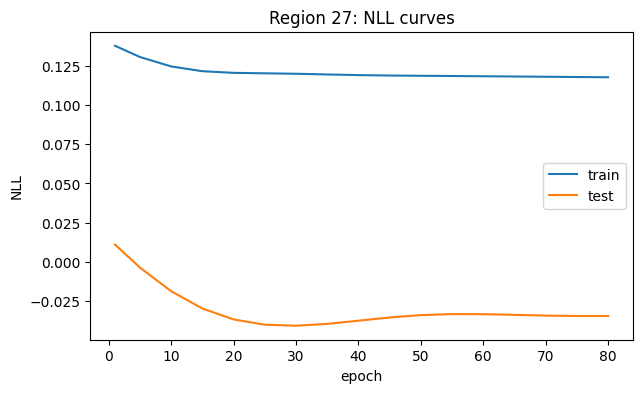

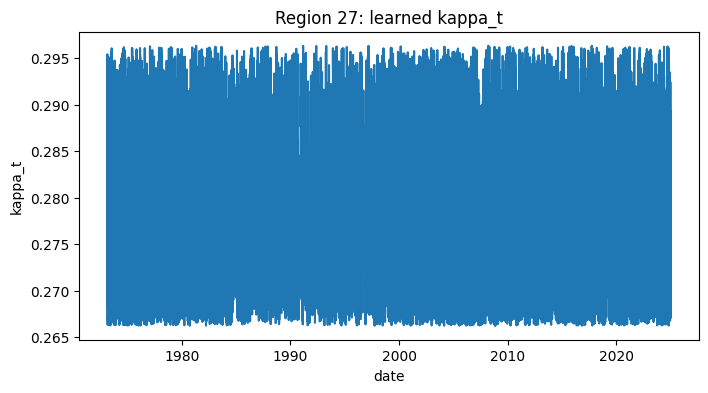

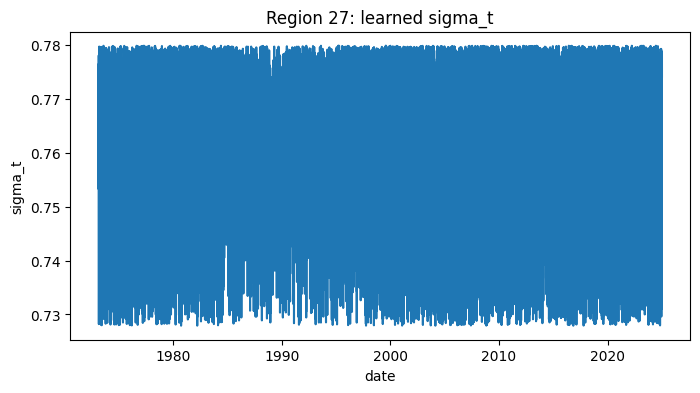

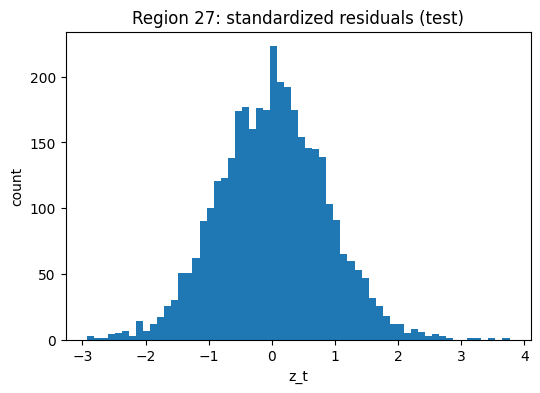

z mean: 0.013797332532703876 z std: 0.8517942428588867
saved model: final_wavelet_models_per_region/region_27_final_model.pt


In [21]:

# ============================================================
# FINAL MODEL DIAGNOSTIC PLOTS FOR ONE REGION
# ============================================================

REGION_TO_PLOT = GRID_REGIONS[2]

art = final_region_artifacts[REGION_TO_PLOT]
dfr = art["df"]
dates_k = dfr.loc[art["idx_t"], "date"].values

plt.figure(figsize=(7,4))
plt.plot(art["epochs_logged"], art["train_curve"], label="train")
plt.plot(art["epochs_logged"], art["test_curve"], label="test")
plt.title(f"Region {REGION_TO_PLOT}: NLL curves")
plt.xlabel("epoch")
plt.ylabel("NLL")
plt.legend()
plt.show()

plt.figure(figsize=(8,4))
plt.plot(dates_k, art["kappa_all"])
plt.title(f"Region {REGION_TO_PLOT}: learned kappa_t")
plt.xlabel("date")
plt.ylabel("kappa_t")
plt.show()

plt.figure(figsize=(8,4))
plt.plot(dates_k, art["sigma_all"])
plt.title(f"Region {REGION_TO_PLOT}: learned sigma_t")
plt.xlabel("date")
plt.ylabel("sigma_t")
plt.show()

plt.figure(figsize=(6,4))
plt.hist(art["z_test"], bins=60)
plt.title(f"Region {REGION_TO_PLOT}: standardized residuals (test)")
plt.xlabel("z_t")
plt.ylabel("count")
plt.show()

print("z mean:", float(np.mean(art["z_test"])), "z std:", float(np.std(art["z_test"])))
print("saved model:", art["save_path"])


In [17]:
# ============================================================
# FINAL SUMMARY TABLE
# ============================================================

final_summary[[
    "region", "n_wavelets", "wavelet", "head_hidden",
    "test_nll", "mae", "rmse", "r2", "corr",
    "picp_90", "coverage_error_90", "z_mean", "z_std", "z_skew", "z_kurtosis"
]]


,region,n_wavelets,wavelet,head_hidden,test_nll,mae,rmse,r2,corr,picp_90,coverage_error_90,z_mean,z_std,z_skew,z_kurtosis
0,11,2,morlet,0,-0.009650,1.608361,2.013911,0.608535,0.780153,0.906627,0.006627,0.010942,0.982470,0.109154,3.045735
1,24,1,mexican_hat,0,-0.021384,1.611076,2.003242,0.618230,0.786597,0.913746,0.013746,0.010048,0.977099,0.113987,3.006647
2,27,2,mexican_hat,16,-0.040874,1.530160,1.935798,0.653397,0.810046,0.949055,0.049055,0.013797,0.851794,0.068824,3.305135
3,28,1,morlet,0,0.040523,1.292746,1.656904,0.615628,0.784780,0.902245,0.002245,0.018900,1.009082,0.300331,3.475322
4,32,2,mexican_hat,16,-0.035400,1.428264,1.812609,0.621054,0.789153,0.942223,0.042223,0.008069,0.868900,0.317962,3.275399
5,44,8,mexican_hat,16,-0.119829,1.452146,1.842547,0.677715,0.823576,0.901972,0.001972,0.014379,0.991718,0.134604,3.358088
6,52,8,mexican_hat,16,-0.013020,1.472091,1.855918,0.605176,0.777995,0.918127,0.018127,0.013524,0.946129,0.190709,3.160187
7,53,1,mexican_hat,0,-0.024657,1.203005,1.531468,0.595842,0.771948,0.913472,0.013472,-0.002368,0.964915,0.277472,3.287993


# Final OU-WNN model architecture (matched input design)

In [18]:
# ============================================================
# FINAL MODEL TRAINING SETUP
# ============================================================

USE_GLOBAL_ARCH = False

# If using one global architecture for all regions:
FINAL_N_WAVELETS = 5
FINAL_WAVELET = "mexican_hat"
FINAL_HEAD_HIDDEN = 16

FINAL_EPOCHS = 2000
EARLY_STOPPING = True
EARLY_STOP_PATIENCE = 10
EARLY_STOP_MIN_DELTA = 1e-4
EVAL_EVERY = 25
FINAL_LR = 1e-3
FINAL_KAPPA_MAX = 0.5
FINAL_WEIGHT_DECAY = 0.0
FINAL_GRAD_CLIP = 1.0

train_end_date = pd.Timestamp("2014-12-31")
test_end_date = pd.Timestamp("2024-12-31")

FINAL_MODEL_DIR = "final_wavelet_models_per_region"
os.makedirs(FINAL_MODEL_DIR, exist_ok=True)


In [19]:
# ============================================================
# EXPORT OU-WNN TEMPERATURE MODELS TO PKL
# ============================================================

import pickle
from pathlib import Path

CALIB_END = "2014-12-31"
OUT_DIR = Path("../Outputs/OUWNNParametersRegionSpecific/")
OUT_DIR.mkdir(parents=True, exist_ok=True)
MODEL_NAME = "WNN-OU Temperature Model (Region-Specific Architecture)"

def export_ou_wnn_models_to_pkls(
    regions_to_export,
    final_models,
    final_region_artifacts,
    calib_end=CALIB_END,
    out_dir=OUT_DIR,
    save_combined=True,
):
    region_models = {}

    for reg in regions_to_export:
        if reg not in final_models or reg not in final_region_artifacts:
            print(f"Skipping region {reg}: model/artifact not found")
            continue

        art = final_region_artifacts[reg]
        model = final_models[reg]
        arch = art["arch"]

        model_dict = {
            "model_name": MODEL_NAME,
            "region_code": int(reg),
            "calib_end": str(calib_end),
            "window": int(WINDOW),
            "doy_harmonics": int(DOY_HARMONICS),
            "wnn_architecture": {
                "n_wavelets": int(arch["n_wavelets"]),
                "wavelet": str(arch["wavelet"]),
                "head_hidden": int(arch["head_hidden"]),
                "kappa_max": float(FINAL_KAPPA_MAX),
            },
            "wnn_state_dict": {k: v.detach().cpu() for k, v in model.state_dict().items()},
            "x_mean": float(art["x_mean"]),
            "x_std": float(art["x_std"]),
            "seasonality_beta": art["beta"],
            "diagnostics": {
                "test_nll": float(art["metrics"]["test_nll"]),
                "mae": float(art["metrics"]["mae"]),
                "rmse": float(art["metrics"]["rmse"]),
                "r2": float(art["metrics"]["r2"]),
                "corr": float(art["metrics"]["corr"]),
                "picp_90": float(art["metrics"]["picp_90"]),
                "coverage_error_90": float(art["metrics"]["coverage_error_90"]),
                "z_mean": float(art["metrics"]["z_mean"]),
                "z_std": float(art["metrics"]["z_std"]),
                "z_skew": float(art["metrics"]["z_skew"]),
                "z_kurtosis": float(art["metrics"]["z_kurtosis"]),
            },
            "n_obs_train": int(np.sum(art["train_mask"])),
            "n_obs_test": int(np.sum(art["test_mask"])),
        }

        fname = out_dir / f"ou_wnn_region_{int(reg):02d}_calib_end_{calib_end}.pkl"
        with open(fname, "wb") as f:
            pickle.dump(model_dict, f)
        print(f"Saved -> {fname}")

        region_models[int(reg)] = model_dict

    if save_combined:
        combined = {
            "model_name": MODEL_NAME,
            "calib_end": str(calib_end),
            "regions": sorted(region_models.keys()),
            "models_by_region": region_models,
        }

        fname_all = out_dir / f"ou_wnn_all_regions_calib_end_{calib_end}.pkl"
        with open(fname_all, "wb") as f:
            pickle.dump(combined, f)
        print(f"Saved -> {fname_all}")

    return region_models

ou_wnn_models = export_ou_wnn_models_to_pkls(
    regions_to_export=GRID_REGIONS,
    final_models=final_models,
    final_region_artifacts=final_region_artifacts,
)


Saved -> ../Outputs/OUWNNParametersRegionSpecific/ou_wnn_region_11_calib_end_2014-12-31.pkl
Saved -> ../Outputs/OUWNNParametersRegionSpecific/ou_wnn_region_24_calib_end_2014-12-31.pkl
Saved -> ../Outputs/OUWNNParametersRegionSpecific/ou_wnn_region_27_calib_end_2014-12-31.pkl
Saved -> ../Outputs/OUWNNParametersRegionSpecific/ou_wnn_region_28_calib_end_2014-12-31.pkl
Saved -> ../Outputs/OUWNNParametersRegionSpecific/ou_wnn_region_32_calib_end_2014-12-31.pkl
Saved -> ../Outputs/OUWNNParametersRegionSpecific/ou_wnn_region_44_calib_end_2014-12-31.pkl
Saved -> ../Outputs/OUWNNParametersRegionSpecific/ou_wnn_region_52_calib_end_2014-12-31.pkl
Saved -> ../Outputs/OUWNNParametersRegionSpecific/ou_wnn_region_53_calib_end_2014-12-31.pkl
Saved -> ../Outputs/OUWNNParametersRegionSpecific/ou_wnn_all_regions_calib_end_2014-12-31.pkl
